# PAN25 — Exploratory Data Analysis
**Dataset:** PAN25 LLM Detection Corpus (23-class authorship attribution: 22 LLM sources + human)  
**Goal:** Understand the data fed to BERT and identify potential risk areas before classification.

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import json, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

DATA_DIR = '/content/drive/MyDrive/ap-thesis/data/pan25'

with open(f'{DATA_DIR}/train.jsonl', 'r', encoding='utf-8') as f:
    train_raw = [json.loads(line) for line in f]
with open(f'{DATA_DIR}/val.jsonl', 'r', encoding='utf-8') as f:
    val_raw = [json.loads(line) for line in f]

train = pd.DataFrame(train_raw)
val   = pd.DataFrame(val_raw)

train['split'] = 'train'
val['split']   = 'val'

for frame in [train, val]:
    frame['char_len']   = frame['text'].str.len()
    frame['word_count'] = frame['text'].str.split().str.len()
    frame['is_human']   = (frame['model'] == 'human').astype(int)

df = pd.concat([train, val], ignore_index=True)

print(f'Train: {len(train):,}  |  Val: {len(val):,}  |  Total: {len(df):,}')
print(f'Classes (models): {df["model"].nunique()}')
print(f'Genres: {df["genre"].unique().tolist()}')

Train: 23,707  |  Val: 3,589  |  Total: 27,296
Classes (models): 23
Genres: ['essays', 'fiction', 'news']


## 1 - Overall Size & Split Ratio

In [ ]:
split_counts = df.groupby('split').size().rename('samples')
print(split_counts)
print(f'\nTrain / Val ratio: {len(train)/len(val):.2f} : 1')
print(f'Val share: {len(val)/len(df)*100:.1f}%')

split
train    23707
val       3589
Name: samples, dtype: int64

Train / Val ratio: 6.61 : 1
Val share: 13.1%


## 2 - Class Distribution

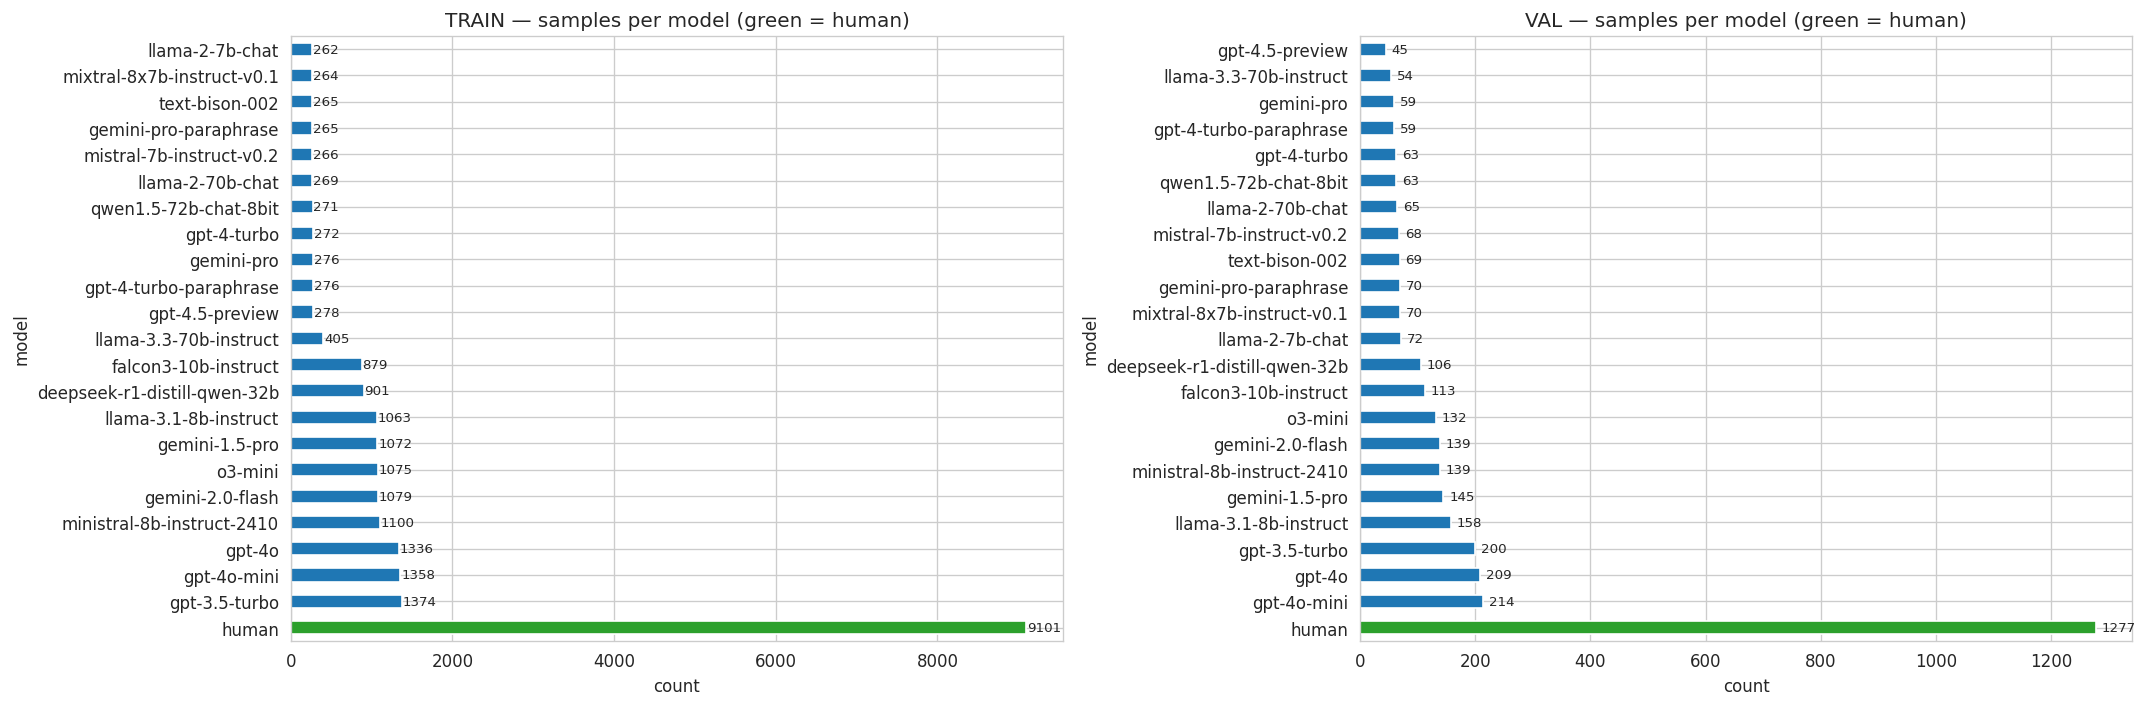

Train — max/min class ratio: 9101/262 = 34.7x
Val   — max/min class ratio: 1277/45 = 28.4x

Train human share: 38.4%
Val   human share: 35.6%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, split in zip(axes, ['train', 'val']):
    subset = df[df['split'] == split]
    counts = subset['model'].value_counts()
    colors = ['#2ca02c' if m == 'human' else '#1f77b4' for m in counts.index]
    counts.plot.barh(ax=ax, color=colors)
    ax.set_title(f'{split.upper()} — samples per model (green = human)', fontsize=12)
    ax.set_xlabel('count')
    for i, v in enumerate(counts):
        ax.text(v + 10, i, str(v), va='center', fontsize=8)

plt.tight_layout()
plt.show()

# imbalance summary
train_counts = train['model'].value_counts()
val_counts   = val['model'].value_counts()
print(f'Train — max/min class ratio: {train_counts.max()}/{train_counts.min()} = {train_counts.max()/train_counts.min():.1f}x')
print(f'Val   — max/min class ratio: {val_counts.max()}/{val_counts.min()} = {val_counts.max()/val_counts.min():.1f}x')
print(f'\nTrain human share: {(train["model"]=="human").mean()*100:.1f}%')
print(f'Val   human share: {(val["model"]=="human").mean()*100:.1f}%')

### ⚠️ Risk: Severe class imbalance
- **human** has ~35× more samples than the smallest LLM class.
- BERT may overfit to majority class -> balanced accuracy needed.
- Consider: class weights, oversampling, or stratified batching.

## 3 - Binary view: Human vs LLM

Train: human=9101 (38.4%)  LLM=14606 (61.6%)
Val: human=1277 (35.6%)  LLM=2312 (64.4%)


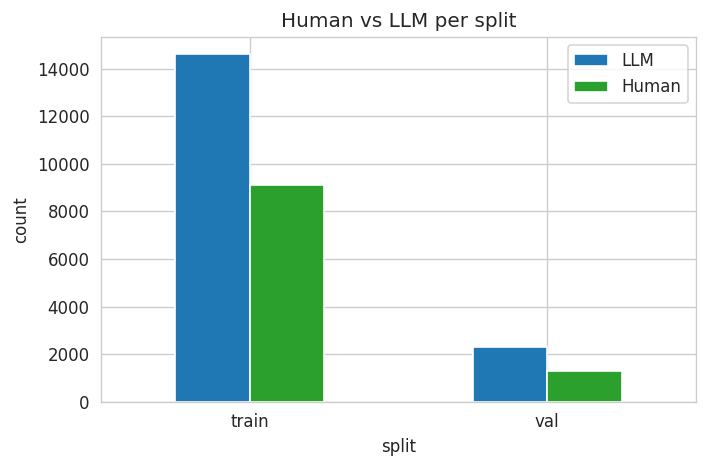

In [ ]:
for split_name, subset in [('Train', train), ('Val', val)]:
    h = (subset['model'] == 'human').sum()
    l = len(subset) - h
    print(f'{split_name}: human={h} ({h/len(subset)*100:.1f}%)  LLM={l} ({l/len(subset)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(6, 4))
binary = df.groupby(['split', 'is_human']).size().unstack(fill_value=0)
binary.columns = ['LLM', 'Human']
binary.plot.bar(ax=ax, color=['#1f77b4', '#2ca02c'])
ax.set_title('Human vs LLM per split')
ax.set_ylabel('count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4 - Genre Distribution & Genre × Model Confound

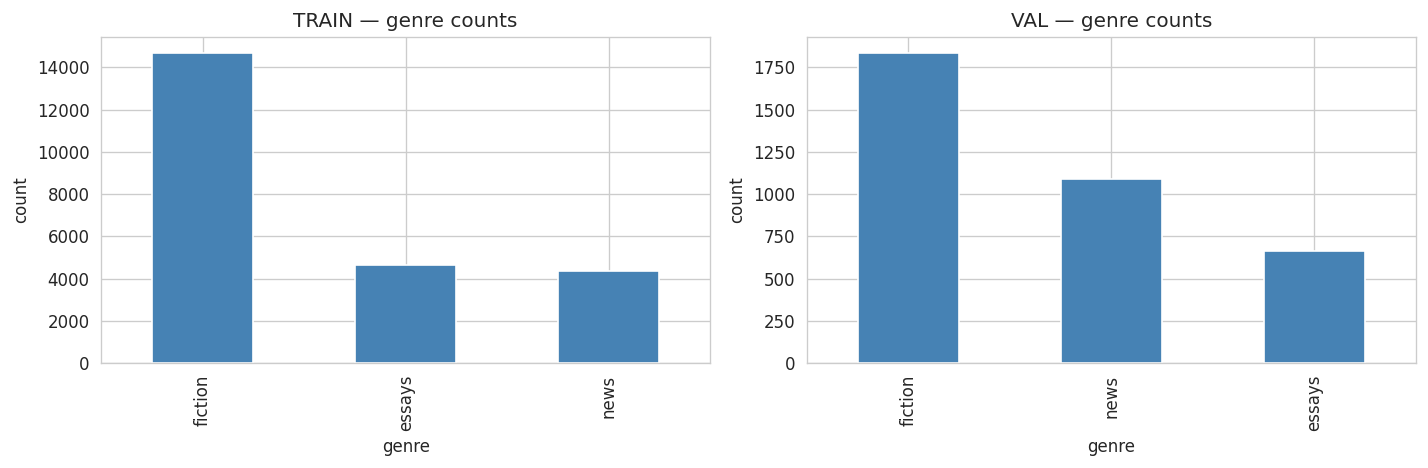

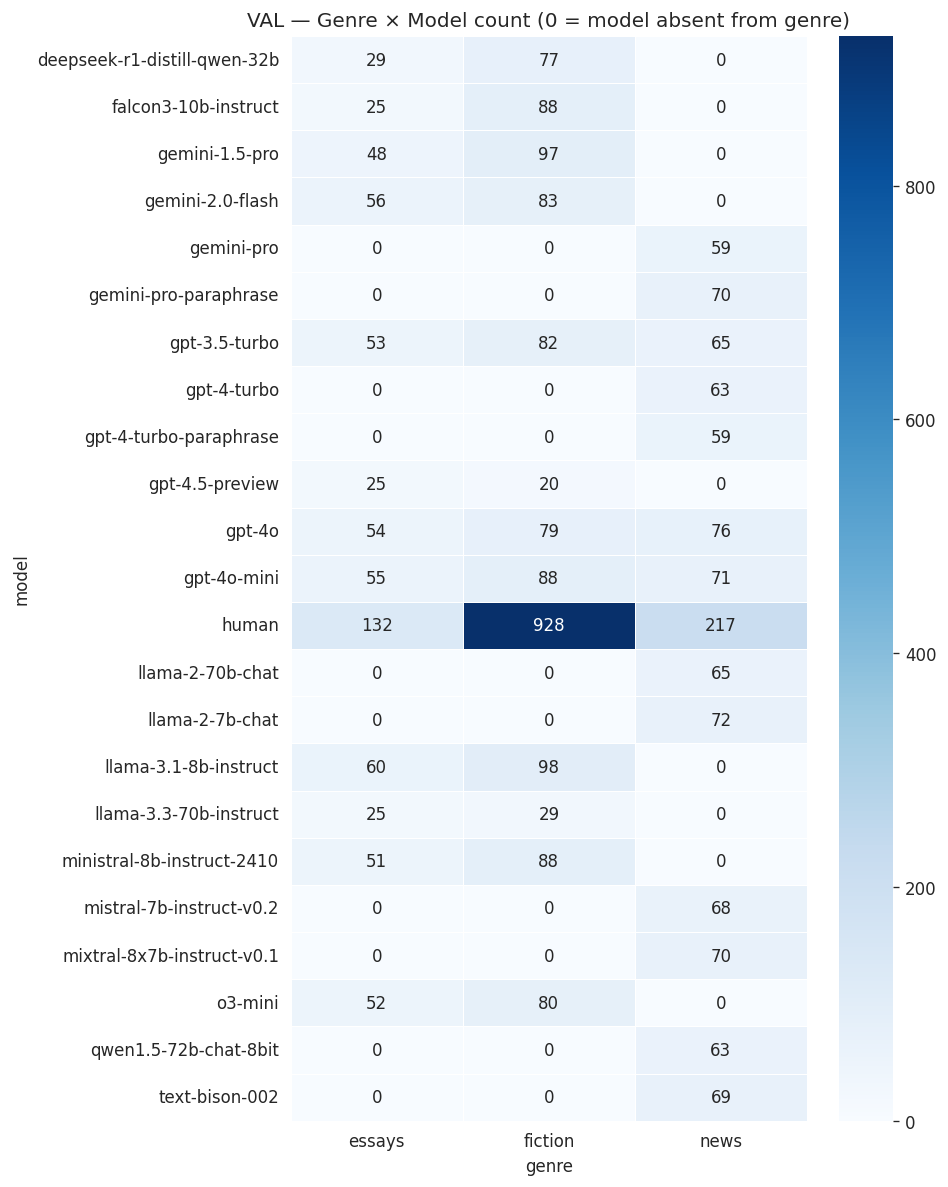

In [ ]:
# genre counts
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, split in zip(axes, ['train', 'val']):
    df[df['split']==split]['genre'].value_counts().plot.bar(ax=ax, color='steelblue')
    ax.set_title(f'{split.upper()} — genre counts')
    ax.set_ylabel('count')
plt.tight_layout()
plt.show()

# genre x model heatmap (val)
ct = pd.crosstab(val['model'], val['genre'])
fig, ax = plt.subplots(figsize=(8, 10))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', ax=ax, linewidths=0.5)
ax.set_title('VAL — Genre × Model count (0 = model absent from genre)')
plt.tight_layout()
plt.show()

### ⚠️ Risk: Genre–Model confound
- Several models appear in **only one genre** (e.g. gemini-pro -> news only, gpt-4-turbo -> news only).
- BERT could learn to classify by topic/genre cues rather than true stylistic fingerprints.
- Only `gpt-3.5-turbo`, `gpt-4o`, `gpt-4o-mini`, and `human` span all three genres.
- This is a **major confound** — any attribution finding for single-genre models may reflect genre, not author.

## 5 - Text Length Distribution

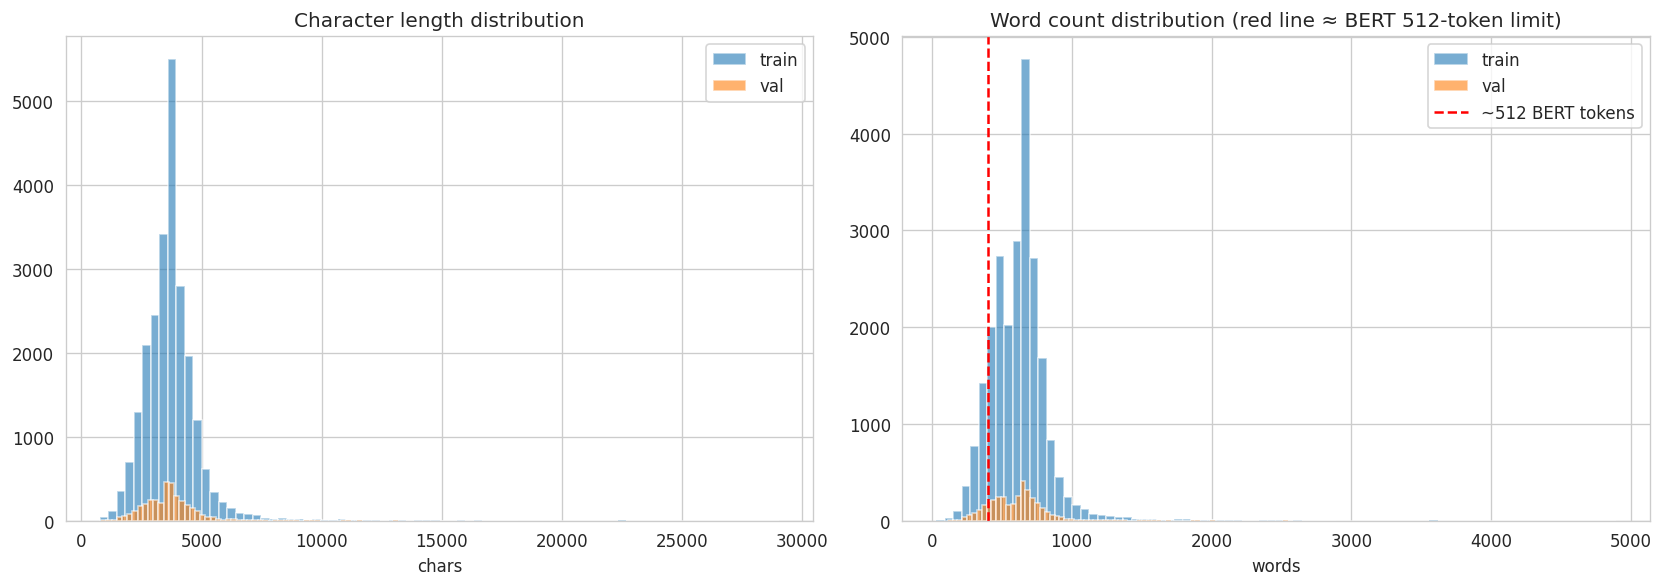

         count   mean    std    min    25%    50%    75%     max
split                                                           
train  23707.0  621.0  211.0   33.0  489.0  635.0  714.0  4892.0
val     3589.0  608.0  225.0  114.0  465.0  616.0  707.0  2892.0


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# character length
for split in ['train', 'val']:
    axes[0].hist(df[df['split']==split]['char_len'], bins=80, alpha=0.6, label=split)
axes[0].set_title('Character length distribution')
axes[0].set_xlabel('chars')
axes[0].legend()

# word count
for split in ['train', 'val']:
    axes[1].hist(df[df['split']==split]['word_count'], bins=80, alpha=0.6, label=split)
axes[1].axvline(400, color='red', ls='--', label='~512 BERT tokens')
axes[1].set_title('Word count distribution (red line ≈ BERT 512-token limit)')
axes[1].set_xlabel('words')
axes[1].legend()

plt.tight_layout()
plt.show()

print(df.groupby('split')['word_count'].describe().round(0))

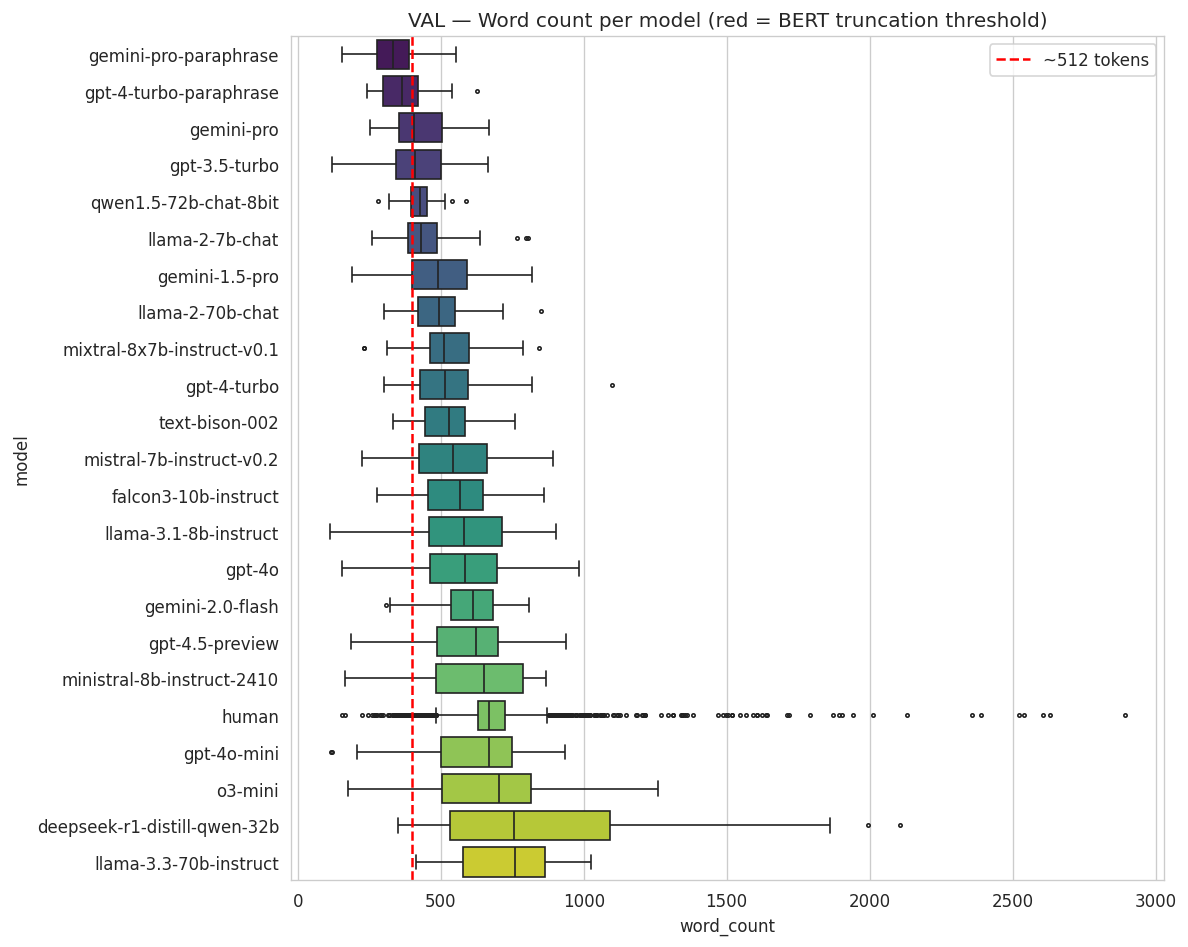

In [ ]:
# text length by model (val) — boxplot
order = val.groupby('model')['word_count'].median().sort_values().index
fig, ax = plt.subplots(figsize=(10, 8))
sns.boxplot(data=val, y='model', x='word_count', order=order, ax=ax,
            fliersize=2, palette='viridis')
ax.axvline(400, color='red', ls='--', lw=1.5, label='~512 tokens')
ax.set_title('VAL — Word count per model (red = BERT truncation threshold)')
ax.legend()
plt.tight_layout()
plt.show()

### ⚠️ Risk: Massive truncation
- **85% of validation texts exceed ~400 words** (~512 BERT tokens) → most texts are truncated.
- Truncation is **uneven across models**: gemini-pro-paraphrase only 19% truncated vs llama-3.3-70b 100%.
- BERT only sees the **first ~512 tokens** — if a model's distinctive style appears later in text, it's lost.
- Paraphrase models write shorter → less truncation → possible length-based shortcut.

## 6 - Truncation Risk Per Model

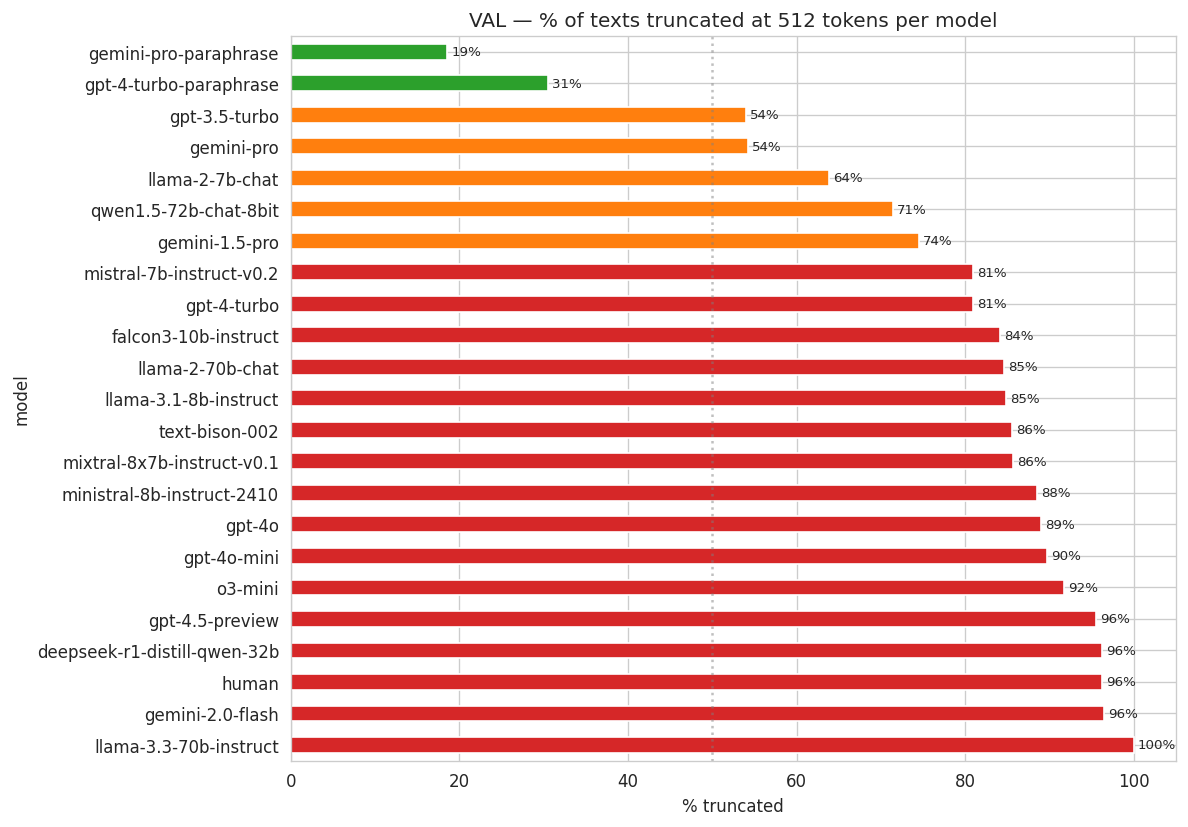

In [ ]:
WORD_THRESHOLD = 400  # approx 512 BERT tokens

trunc = val.copy()
trunc['truncated'] = trunc['word_count'] > WORD_THRESHOLD
trunc_pct = trunc.groupby('model')['truncated'].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#d62728' if v > 80 else '#ff7f0e' if v > 50 else '#2ca02c' for v in trunc_pct]
trunc_pct.plot.barh(ax=ax, color=colors)
ax.set_title('VAL — % of texts truncated at 512 tokens per model')
ax.set_xlabel('% truncated')
ax.axvline(50, color='gray', ls=':', alpha=0.5)
for i, v in enumerate(trunc_pct):
    ax.text(v + 0.5, i, f'{v:.0f}%', va='center', fontsize=8)
plt.tight_layout()
plt.show()

## 7 - Duplicate & Overlap Check

In [ ]:
train_texts = set(train['text'])
val_texts   = set(val['text'])

train_dupes = len(train) - len(train_texts)
val_dupes   = len(val)   - len(val_texts)
overlap     = train_texts & val_texts

print(f'Train duplicates: {train_dupes} / {len(train)}')
print(f'Val duplicates:   {val_dupes} / {len(val)}')
print(f'Train ↔ Val overlap: {len(overlap)} texts')

if overlap:
    print('\n⚠️  Overlapping texts (data leakage risk):')
    for t in list(overlap)[:5]:
        row = train[train['text']==t].iloc[0]
        print(f'  [{row["model"]}] "{t[:80]}..."')

Train duplicates: 25 / 23707
Val duplicates:   0 / 3589
Train ↔ Val overlap: 3 texts

⚠️  Overlapping texts (data leakage risk):
  [human] "“I say, my father’s past,” said Charlie. “Won’t he be pleased to find you two gi..."
  [human] "“Well, Charlie, a man can do anything,” said Agnes; “we are obliged to put up wi..."
  [human] "Donald J. Trump

The biography for President Trump and past presidents is courte..."


### ⚠️ Risk: Minor data leakage
- 25 train duplicates + **3 train–val overlapping texts** = potential leakage.
- Impact is minimal (3 out of 3,589) but should be documented.

## 8 - Label Encoding Check

In [ ]:
# verify label assignment
label_model = df.groupby('label')['model'].unique()
print('Label → Model mapping:')
print(f'  Label 0: {label_model[0]}')
print(f'  Label 1: {label_model[1]} ({len(label_model[1])} models)')
print(f'\n⚠️  All 22 LLMs share label=1 → this is BINARY (human vs LLM), not 23-class!')
print('    If doing 23-class, labels must be re-mapped (one per model).')

Label → Model mapping:
  Label 0: ['human']
  Label 1: ['falcon3-10b-instruct' 'o3-mini' 'gpt-4o' 'deepseek-r1-distill-qwen-32b'
 'gemini-2.0-flash' 'llama-3.3-70b-instruct' 'gemini-1.5-pro'
 'gpt-4o-mini' 'gpt-3.5-turbo' 'gpt-4.5-preview' 'llama-3.1-8b-instruct'
 'ministral-8b-instruct-2410' 'gemini-pro-paraphrase' 'gpt-4-turbo'
 'llama-2-7b-chat' 'llama-2-70b-chat' 'text-bison-002'
 'mixtral-8x7b-instruct-v0.1' 'gpt-4-turbo-paraphrase'
 'qwen1.5-72b-chat-8bit' 'mistral-7b-instruct-v0.2' 'gemini-pro'] (22 models)

⚠️  All 22 LLMs share label=1 → this is BINARY (human vs LLM), not 23-class!
    If doing 23-class, labels must be re-mapped (one per model).


### ⚠️ Risk: Label semantics
- Raw labels are **binary** (0=human, 1=LLM) — 22 different LLMs all share label 1.
- For 23-class attribution, labels must be **re-encoded** (one label per model).
- If this re-encoding is inconsistent between train/val, results are invalid.

## 9 - Text Statistics by Model

In [ ]:
# compute richer stats
df['avg_word_len'] = df['text'].apply(lambda t: np.mean([len(w) for w in t.split()]))
df['unique_words'] = df['text'].apply(lambda t: len(set(t.lower().split())))
df['ttr'] = df['unique_words'] / df['word_count']  # type-token ratio
df['sent_count'] = df['text'].str.count(r'[.!?]+')
df['avg_sent_len'] = df['word_count'] / df['sent_count'].replace(0, np.nan)

stats = val.copy()
stats['avg_word_len'] = stats['text'].apply(lambda t: np.mean([len(w) for w in t.split()]))
stats['unique_words'] = stats['text'].apply(lambda t: len(set(t.lower().split())))
stats['ttr'] = stats['unique_words'] / stats['word_count']
stats['sent_count'] = stats['text'].str.count(r'[.!?]+')
stats['avg_sent_len'] = stats['word_count'] / stats['sent_count'].replace(0, np.nan)

summary = stats.groupby('model').agg(
    n=('text', 'size'),
    word_count_mean=('word_count', 'mean'),
    avg_word_len=('avg_word_len', 'mean'),
    ttr_mean=('ttr', 'mean'),
    avg_sent_len=('avg_sent_len', 'mean'),
).round(2)

print(summary.to_string())

                                 n  word_count_mean  avg_word_len  ttr_mean  avg_sent_len
model                                                                                    
deepseek-r1-distill-qwen-32b   106           852.74          4.99      0.51         18.28
falcon3-10b-instruct           113           557.31          5.15      0.59         19.63
gemini-1.5-pro                 145           496.48          5.19      0.60         18.19
gemini-2.0-flash               139           605.98          5.33      0.59         17.14
gemini-pro                      59           425.49          5.35      0.55         17.33
gemini-pro-paraphrase           70           337.96          5.51      0.62         18.09
gpt-3.5-turbo                  200           415.83          5.32      0.57         21.62
gpt-4-turbo                     63           519.63          5.58      0.58         22.34
gpt-4-turbo-paraphrase          59           366.31          5.62      0.63         22.59
gpt-4.5-pr

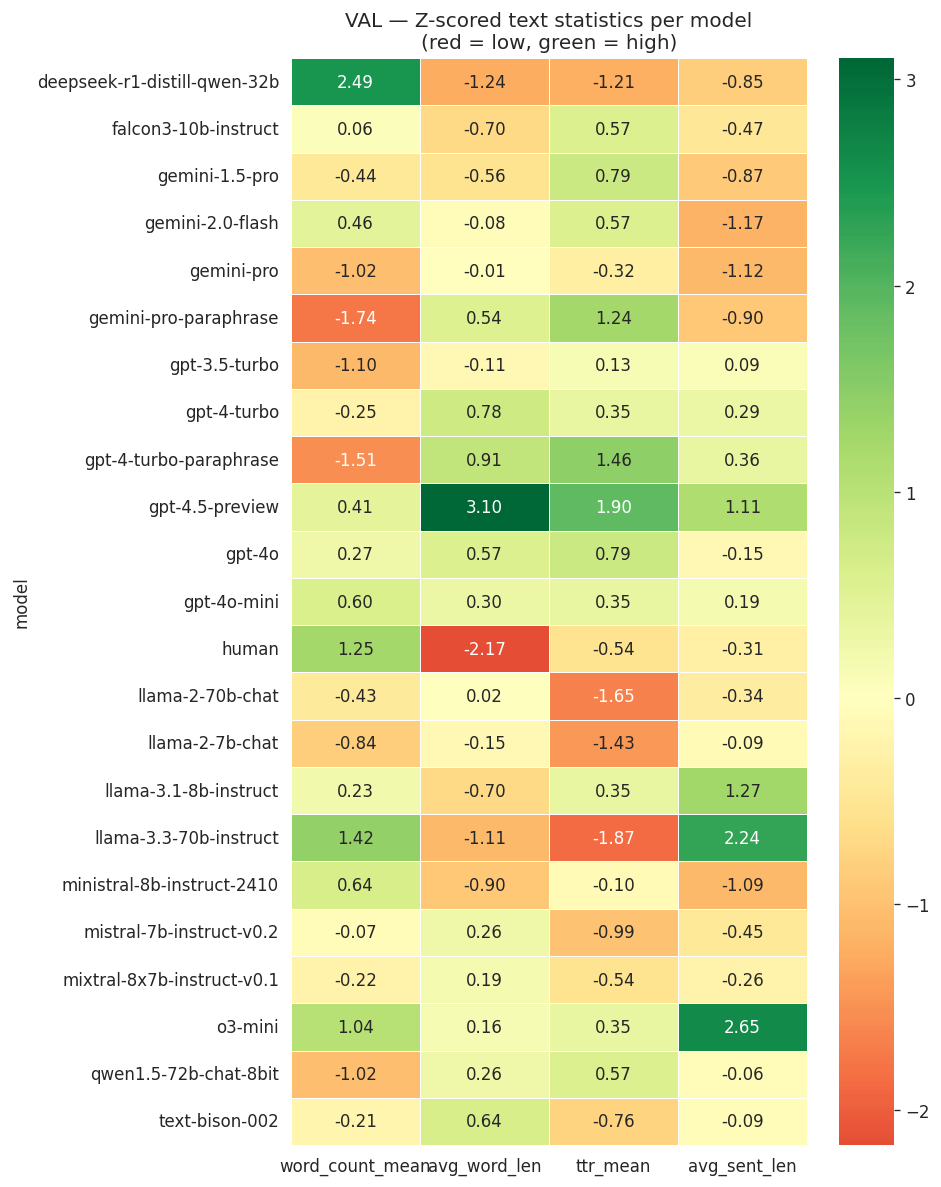

In [ ]:
# heatmap of normalized stats
norm = summary.drop(columns='n')
norm = (norm - norm.mean()) / norm.std()  # z-score

fig, ax = plt.subplots(figsize=(8, 10))
sns.heatmap(norm, cmap='RdYlGn', center=0, annot=True, fmt='.2f', ax=ax, linewidths=0.5)
ax.set_title('VAL — Z-scored text statistics per model\n(red = low, green = high)')
plt.tight_layout()
plt.show()

### ⚠️ Risk: Surface-level shortcuts
- If models differ significantly in **word length**, **type-token ratio**, or **sentence length**, BERT can learn these shallow cues instead of true style.
- Paraphrase models (gemini-pro-paraphrase, gpt-4-turbo-paraphrase) may have shorter texts and different TTR — these are easy shortcuts.

## 10 - Human vs LLM Statistical Comparison

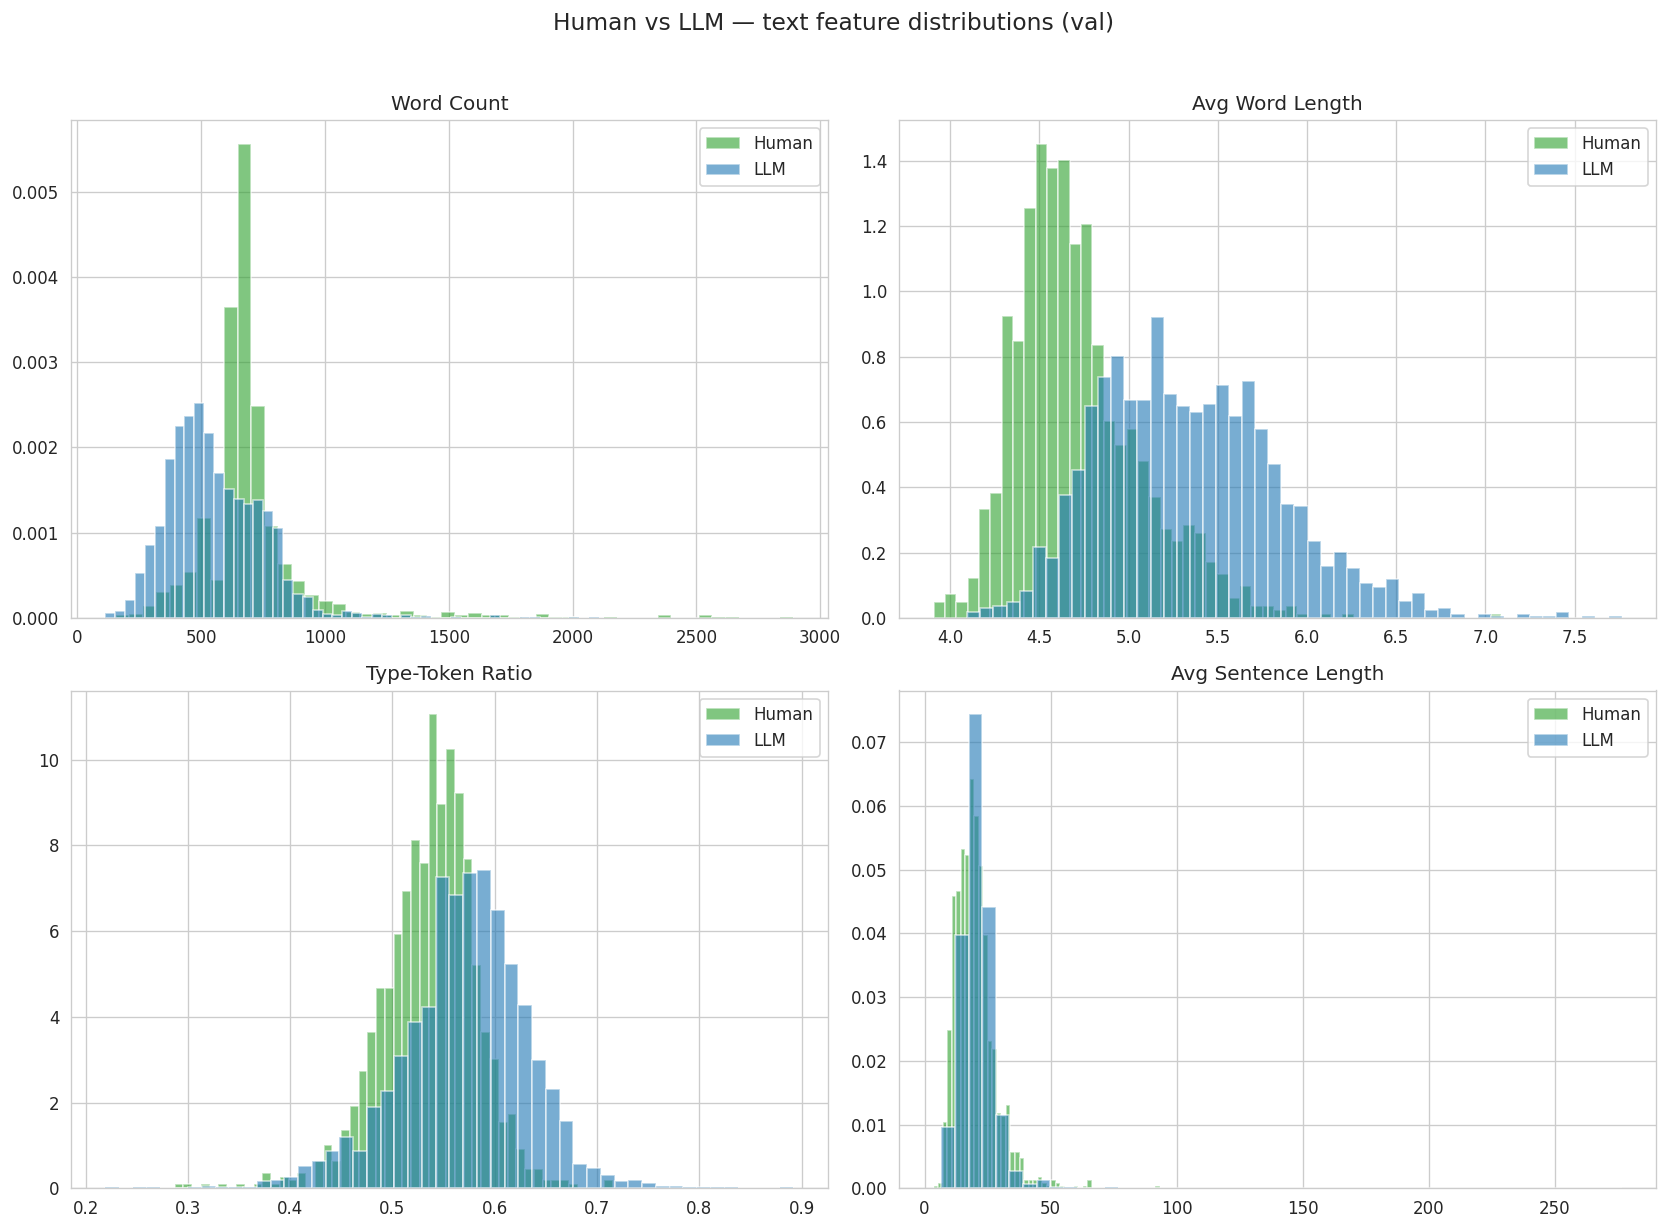

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ['word_count', 'avg_word_len', 'ttr', 'avg_sent_len']
titles = ['Word Count', 'Avg Word Length', 'Type-Token Ratio', 'Avg Sentence Length']

human_data = stats[stats['model'] == 'human']
llm_data   = stats[stats['model'] != 'human']

for ax, metric, title in zip(axes.flat, metrics, titles):
    ax.hist(human_data[metric].dropna(), bins=50, alpha=0.6, label='Human', color='#2ca02c', density=True)
    ax.hist(llm_data[metric].dropna(), bins=50, alpha=0.6, label='LLM', color='#1f77b4', density=True)
    ax.set_title(title)
    ax.legend()

plt.suptitle('Human vs LLM — text feature distributions (val)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 11 - Risk Summary Dashboard

In [ ]:
risks = [
    ['Severe class imbalance',       'HIGH',   f'human has {train_counts.max()}; smallest LLM has {train_counts.min()} → {train_counts.max()/train_counts.min():.0f}× gap'],
    ['Genre–Model confound',         'HIGH',   'Many models appear in only 1 genre → BERT may learn topic, not style'],
    ['Massive truncation (512 tok)',  'HIGH',   f'{(val["word_count"]>400).mean()*100:.0f}% of val texts truncated; uneven across models'],
    ['Binary label encoding',        'MEDIUM', 'Raw labels are 0/1 (human/LLM); 23-class requires re-mapping'],
    ['Human vs LLM ratio (38/62)',   'MEDIUM', 'Not balanced binary split; human is minority in label=0'],
    ['Train-Val data leakage',       'LOW',    f'{len(overlap)} overlapping texts between train and val'],
    ['Train duplicates',             'LOW',    f'{train_dupes} duplicate texts in training set'],
    ['Text length as shortcut',      'MEDIUM', 'Paraphrase models are shorter → possible length-based classification'],
]

risk_df = pd.DataFrame(risks, columns=['Risk', 'Severity', 'Detail'])

def color_severity(val):
    colors = {'HIGH': 'background-color: #ffcccc', 'MEDIUM': 'background-color: #fff3cd', 'LOW': 'background-color: #d4edda'}
    return colors.get(val, '')

risk_df.style.applymap(color_severity, subset=['Severity'])

,Risk,Severity,Detail
0,Severe class imbalance,HIGH,human has 9101; smallest LLM has 262 → 35× gap
1,Genre–Model confound,HIGH,"Many models appear in only 1 genre → BERT may learn topic, not style"
2,Massive truncation (512 tok),HIGH,85% of val texts truncated; uneven across models
3,Binary label encoding,MEDIUM,Raw labels are 0/1 (human/LLM); 23-class requires re-mapping
4,Human vs LLM ratio (38/62),MEDIUM,Not balanced binary split; human is minority in label=0
5,Train-Val data leakage,LOW,3 overlapping texts between train and val
6,Train duplicates,LOW,25 duplicate texts in training set
7,Text length as shortcut,MEDIUM,Paraphrase models are shorter → possible length-based classification


## Key Takeaways (BERT Training)

1. **balanced accuracy is required** - raw accuracy is misleading due to the 35× class size gap.  
2. **Genre is a confound** - many models only appear in one genre. BERT may learn topic, not style.  
3. **85% of texts are truncated** - BERT only sees the first ~512 tokens. If later text carries style signals, they are invisible.  
4. **Verify label encoding** - raw labels are binary; 23-class setup needs per-model re-mapping.  
5. **Paraphrase models are outliers** - shorter texts, different TTR → easy shortcuts.  
6. **Minimal leakage** - 3 overlapping train/val texts; document but not critical.